In [1]:
import sys
import os
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

## Training Baseline Models (Huiyu)

#### In this notebook, I train and compare seveal baseline models using the preprocessed dataset generated from `Preprocessing.py`.

In [2]:
project_root = os.path.abspath("..")
sys.path.append(project_root)
print(project_root)

# import the preprocessing function
from src.Preprocessing import get_preprocessed_data

# load preprocessed data, this function returns train/test split data
X_train, X_test, y_train, y_test = get_preprocessed_data()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

c:\Users\yhy_s\Downloads\california-housing
X_train shape: (68395, 36)
X_test shape: (9408, 36)
y_train shape: (68395,)
y_test shape: (9408,)


In [3]:
print("Feature columns:")
print(X_train.columns)

# sanity check: target should not be inside features
assert "ClosePrice" not in X_train.columns

print("\nFeature dtypes:")
print(X_train.dtypes)

# checking if there are any remaining missing values that need to be handled
na_counts = X_train.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print("\nMissing values per column:")
print(na_counts)

Feature columns:
Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'GarageSpaces',
       'LivingArea', 'MainLevelBedrooms', 'NewConstructionYN', 'ParkingTotal',
       'PoolPrivateYN', 'Stories', 'ViewYN', 'YearBuilt', 'LotSizeAcres',
       'LotSizeArea', 'LotSizeSquareFeet', 'AssociationFee', 'DaysOnMarket',
       'sin_closed_date', 'Flooring_Laminate', 'Flooring_Wood',
       'Flooring_Tile', 'Flooring_Bamboo', 'Flooring_Concrete',
       'Flooring_SeeRemarks', 'Flooring_Brick', 'Flooring_Vinyl',
       'Flooring_Stone', 'Flooring_Carpet', 'Levels_MultiSplit',
       'Levels_ThreeOrMore', 'Levels_One', 'Levels_Two'],
      dtype='object')

Feature dtypes:
Latitude                 float64
Longitude                float64
PostalCode               float64
AttachedGarageYN           int32
BathroomsTotalInteger    float64
BedroomsTotal            float64
FireplaceYN                int32
GarageSpaces        

## Handle missing values

#### As we can see above, some features still comtian missing values after preprocessing.

#### I chose to use median imputation to fill missing values.

In [4]:
# Used median imputation for missing values.
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values after imputation (train):",
      X_train_imputed.isna().sum().sum())
print("Missing values after imputation (test):",
      X_test_imputed.isna().sum().sum())

Missing values after imputation (train): 0
Missing values after imputation (test): 0


#### Define evaluation metrics

#### I evaluate the baseline models using RMSE and R-square.

In [5]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name}")
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*30)

#### Train baseline models

In this step, I chose the following models as the baseline starting point:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost

In [6]:
# Linear Regression baseline

lin_model = LinearRegression()
lin_model.fit(X_train_imputed, y_train)
lin_pred = lin_model.predict(X_test_imputed)
evaluate_model("Linear Regression", y_test, lin_pred)


# Ridge Regression baseline

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_imputed, y_train)
ridge_pred = ridge_model.predict(X_test_imputed)
evaluate_model("Ridge Regression", y_test, ridge_pred)


# Random Forest baseline

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_imputed, y_train)
rf_pred = rf_model.predict(X_test_imputed)
evaluate_model("Random Forest", y_test, rf_pred)


# XGBoost baseline

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_model.fit(X_train_imputed, y_train)
xgb_pred = xgb_model.predict(X_test_imputed)
evaluate_model("XGBoost", y_test, xgb_pred)

Linear Regression
RMSE: 0.4165713142552083
R2: 0.5163751109096859
------------------------------
Ridge Regression
RMSE: 0.41656150986631685
R2: 0.5163978757546404
------------------------------
Random Forest
RMSE: 0.21471106867077613
R2: 0.8715190351691094
------------------------------
XGBoost
RMSE: 0.2215109856377843
R2: 0.863252164364249
------------------------------


#### Baseline results summary

##### As we can see from the results, tree-based models perform much better than linear models.

##### Linear / Ridge models reach around 0.53 R-square. Random Forest and XGBoost reach around 0.87 R-square. This shows that the relationship between features and ClosePrice is highly non-linear.


#### Tuning Random Forest

In [7]:
rf_candidates = [
    {
        "model_name": "RF_baseline_reference",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_more_trees",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_shallower_trees",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_regularized_split",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
    {
        "model_name": "RF_stronger_regularization",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
]

rf_tuning_results = []
best_rf_model = None
best_rf_result = None
best_r2 = -np.inf

for config in rf_candidates:
    rf_tuned_model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf_tuned_model.fit(X_train_imputed, y_train)
    rf_tuned_pred = rf_tuned_model.predict(X_test_imputed)

    rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
    r2 = r2_score(y_test, rf_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "R2": r2
    }

    rf_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_r2:
        best_r2 = r2
        best_rf_model = rf_tuned_model
        best_rf_result = result_row


rf_results_df = pd.DataFrame(rf_tuning_results)
rf_results_df = rf_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("Random Forest tuning summary:")
display(rf_results_df)


print("Best Random Forest configuration:")
print(best_rf_result)

best_rf_pred = best_rf_model.predict(X_test_imputed)

print("\nBest tuned Random Forest performance:")
evaluate_model("Best Tuned Random Forest", y_test, best_rf_pred)

Model: RF_baseline_reference
Parameters: {'model_name': 'RF_baseline_reference', 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.21471106867077613
R2: 0.8715190351691094
--------------------------------------------------
Model: RF_more_trees
Parameters: {'model_name': 'RF_more_trees', 'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.21449209677522663
R2: 0.8717809627406647
--------------------------------------------------
Model: RF_shallower_trees
Parameters: {'model_name': 'RF_shallower_trees', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.21628386155450294
R2: 0.8696298539507326
--------------------------------------------------
Model: RF_regularized_split
Parameters: {'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE: 0.2132583022807984
R2: 0.8732517950914549
-------

,model_name,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,R2
0,RF_regularized_split,200,20.0,10,4,0.213258,0.873252
1,RF_more_trees,300,NaN,2,1,0.214492,0.871781
2,RF_baseline_reference,200,NaN,2,1,0.214711,0.871519
3,RF_shallower_trees,200,20.0,2,1,0.216284,0.869630
4,RF_stronger_regularization,300,15.0,10,4,0.223961,0.860211


Best Random Forest configuration:
{'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'RMSE': 0.2132583022807984, 'R2': 0.8732517950914549}

Best tuned Random Forest performance:
Best Tuned Random Forest
RMSE: 0.2132583022807984
R2: 0.8732517950914549
------------------------------


#### Tuning XGBoost

In [8]:
xgb_candidates = [
    {
        "model_name": "XGB_baseline_reference",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_trees",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_lower_learning_rate",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_shallower_trees",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_regularized_sampling",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
    },
]



xgb_tuning_results = []
best_xgb_model = None
best_xgb_result = None
best_xgb_r2 = -np.inf

for config in xgb_candidates:
    xgb_tuned_model = XGBRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_tuned_model.fit(X_train_imputed, y_train)
    xgb_tuned_pred = xgb_tuned_model.predict(X_test_imputed)

    rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
    r2 = r2_score(y_test, xgb_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "RMSE": rmse,
        "R2": r2
    }

    xgb_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_model = xgb_tuned_model
        best_xgb_result = result_row



xgb_results_df = pd.DataFrame(xgb_tuning_results)
xgb_results_df = xgb_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("XGBoost tuning summary:")
display(xgb_results_df)



print("Best XGBoost configuration:")
print(best_xgb_result)

best_xgb_pred = best_xgb_model.predict(X_test_imputed)

print("\nBest tuned XGBoost performance:")
evaluate_model("Best Tuned XGBoost", y_test, best_xgb_pred)

Model: XGB_baseline_reference
Parameters: {'model_name': 'XGB_baseline_reference', 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.2215109856377843
R2: 0.863252164364249
--------------------------------------------------
Model: XGB_more_trees
Parameters: {'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.2164900925211847
R2: 0.8693811143601489
--------------------------------------------------
Model: XGB_lower_learning_rate
Parameters: {'model_name': 'XGB_lower_learning_rate', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.22809773738476166
R2: 0.8549987063551985
--------------------------------------------------
Model: XGB_shallower_trees
Parameters: {'model_name': 'XGB_shallower_trees', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsam

,model_name,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,RMSE,R2
0,XGB_more_trees,300,6,0.10,0.8,0.8,0.216490,0.869381
1,XGB_baseline_reference,200,6,0.10,0.8,0.8,0.221511,0.863252
2,XGB_lower_learning_rate,300,6,0.05,0.8,0.8,0.228098,0.854999
3,XGB_shallower_trees,200,4,0.10,0.8,0.8,0.245820,0.831591
4,XGB_more_regularized_sampling,300,4,0.05,0.7,0.7,0.253137,0.821416


Best XGBoost configuration:
{'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'RMSE': 0.2164900925211847, 'R2': 0.8693811143601489}

Best tuned XGBoost performance:
Best Tuned XGBoost
RMSE: 0.2164900925211847
R2: 0.8693811143601489
------------------------------


#### GridSearchCV for Random Forest

In [9]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train_imputed, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8519293654124924


In [10]:
best_rf = rf_grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_imputed)

evaluate_model("Tuned Random Forest", y_test, rf_tuned_pred)

Tuned Random Forest
RMSE: 0.24169915565232317
R2: 0.8371903327328842
------------------------------


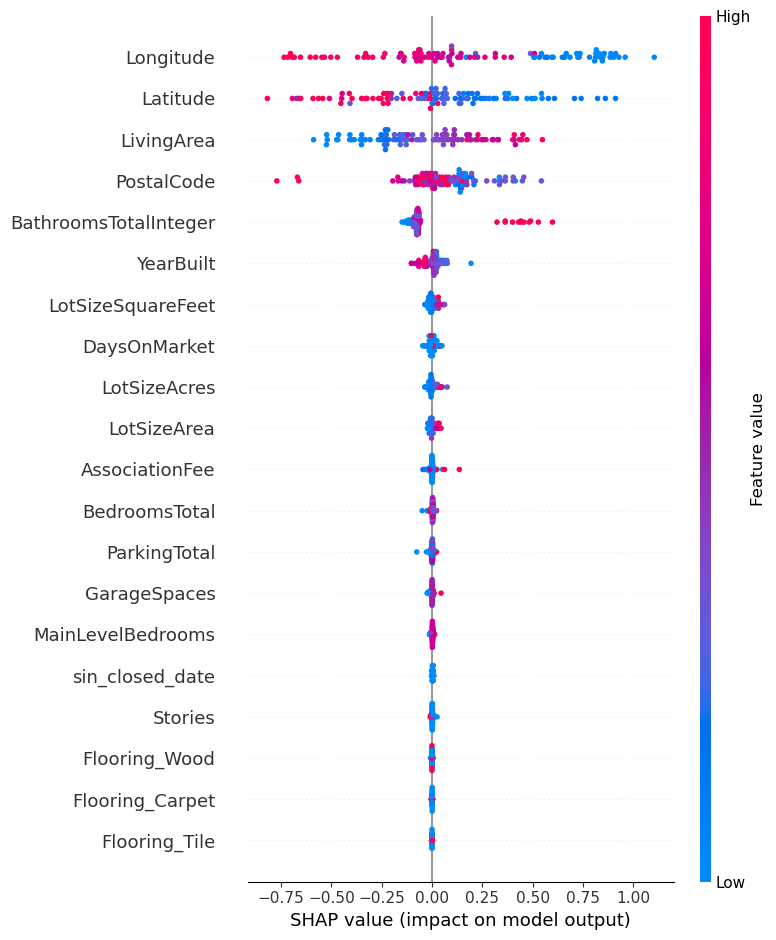

In [11]:
import shap

X_shap = X_test.iloc[:100]
explainer = shap.TreeExplainer(rf_model)   
shap_val = explainer.shap_values(X_shap)
shap.summary_plot(shap_val, X_shap)

#### Linear Regression with Continuous Features

In this section, I explore a simpler linear model using only continuous features.

The goal is to evaluate whether a linear relationship between features and target
can achieve competitive performance compared to tree-based models.

If performance is not satisfactory, I will consider engineering additional features.

In [ ]:
continuous_cols = [
    'Latitude',
    'Longitude',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'GarageSpaces',
    'LivingArea',
    'MainLevelBedrooms',
    'ParkingTotal',
    'Stories',
    'YearBuilt',
    'LotSizeAcres',
    'LotSizeArea',
    'LotSizeSquareFeet',
    'AssociationFee',
    'DaysOnMarket',
    'sin_closed_date'
]

X_train_cont = X_train[continuous_cols]
X_test_cont = X_test[continuous_cols]

lr = LinearRegression()
lr.fit(X_train_cont, y_train)

y_pred = lr.predict(X_test_cont)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE (log scale):", rmse)
print("R^2:", r2)

RMSE (log scale): 0.4168057600478505
R^2: 0.5158305908108873


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### Engineer new features

In [29]:
X_train_cont = X_train_cont.copy()
X_test_cont = X_test_cont.copy()

# Feature engineering
X_train_cont['HouseAge'] = 2026 - X_train_cont['YearBuilt']
X_test_cont['HouseAge'] = 2026 - X_test_cont['YearBuilt']

X_train_cont['AreaPerRoom'] = X_train_cont['LivingArea'] / (X_train_cont['BedroomsTotal'] + 1)
X_test_cont['AreaPerRoom'] = X_test_cont['LivingArea'] / (X_test_cont['BedroomsTotal'] + 1)

X_train_cont['log_LivingArea'] = np.log1p(X_train_cont['LivingArea'])
X_test_cont['log_LivingArea'] = np.log1p(X_test_cont['LivingArea'])

X_train_cont['LivingArea_per_Lot'] = X_train_cont['LivingArea'] / (X_train_cont['LotSizeSquareFeet'] + 1)
X_test_cont['LivingArea_per_Lot'] = X_test_cont['LivingArea'] / (X_test_cont['LotSizeSquareFeet'] + 1)

# Clean after feature engineering
X_train_cont = X_train_cont.replace([np.inf, -np.inf], np.nan)
X_test_cont = X_test_cont.replace([np.inf, -np.inf], np.nan)

X_train_cont = X_train_cont.fillna(X_train_cont.median())
X_test_cont = X_test_cont.fillna(X_train_cont.median())

# Refit model
lr_new = LinearRegression()
lr_new.fit(X_train_cont, y_train)

y_pred_new = lr_new.predict(X_test_cont)

rmse_new = mean_squared_error(y_test, y_pred_new, squared=False)
r2_new = r2_score(y_test, y_pred_new)

print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

New RMSE: 0.41649867113565553
New R^2: 0.5165437685018641


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
print("Baseline RMSE:", rmse)
print("Baseline R^2:", r2)
print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

Baseline RMSE: 0.4168057600478505
Baseline R^2: 0.5158305908108873
New RMSE: 0.41649867113565553
New R^2: 0.5165437685018641
